# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Load models & Date

### Data

In [3]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_232_lrdata.h5ad")

In [4]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

### Normal

In [6]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [7]:
model= mfl.MOFAFLEX.load(models_path / 'crc_232.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### SnS

In [ ]:
#!ls "/g/stegle/aalsayah/repos/data/models_obj/sns_models/crc_232_no_mye_IgM/Normal.SnS"

crc_232_no_mye_IgM.Normal.SnS.hdf5


In [60]:
model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_232_no_mye_IgM/Normal.SnS/crc_232_no_mye_IgM.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [3]:
model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

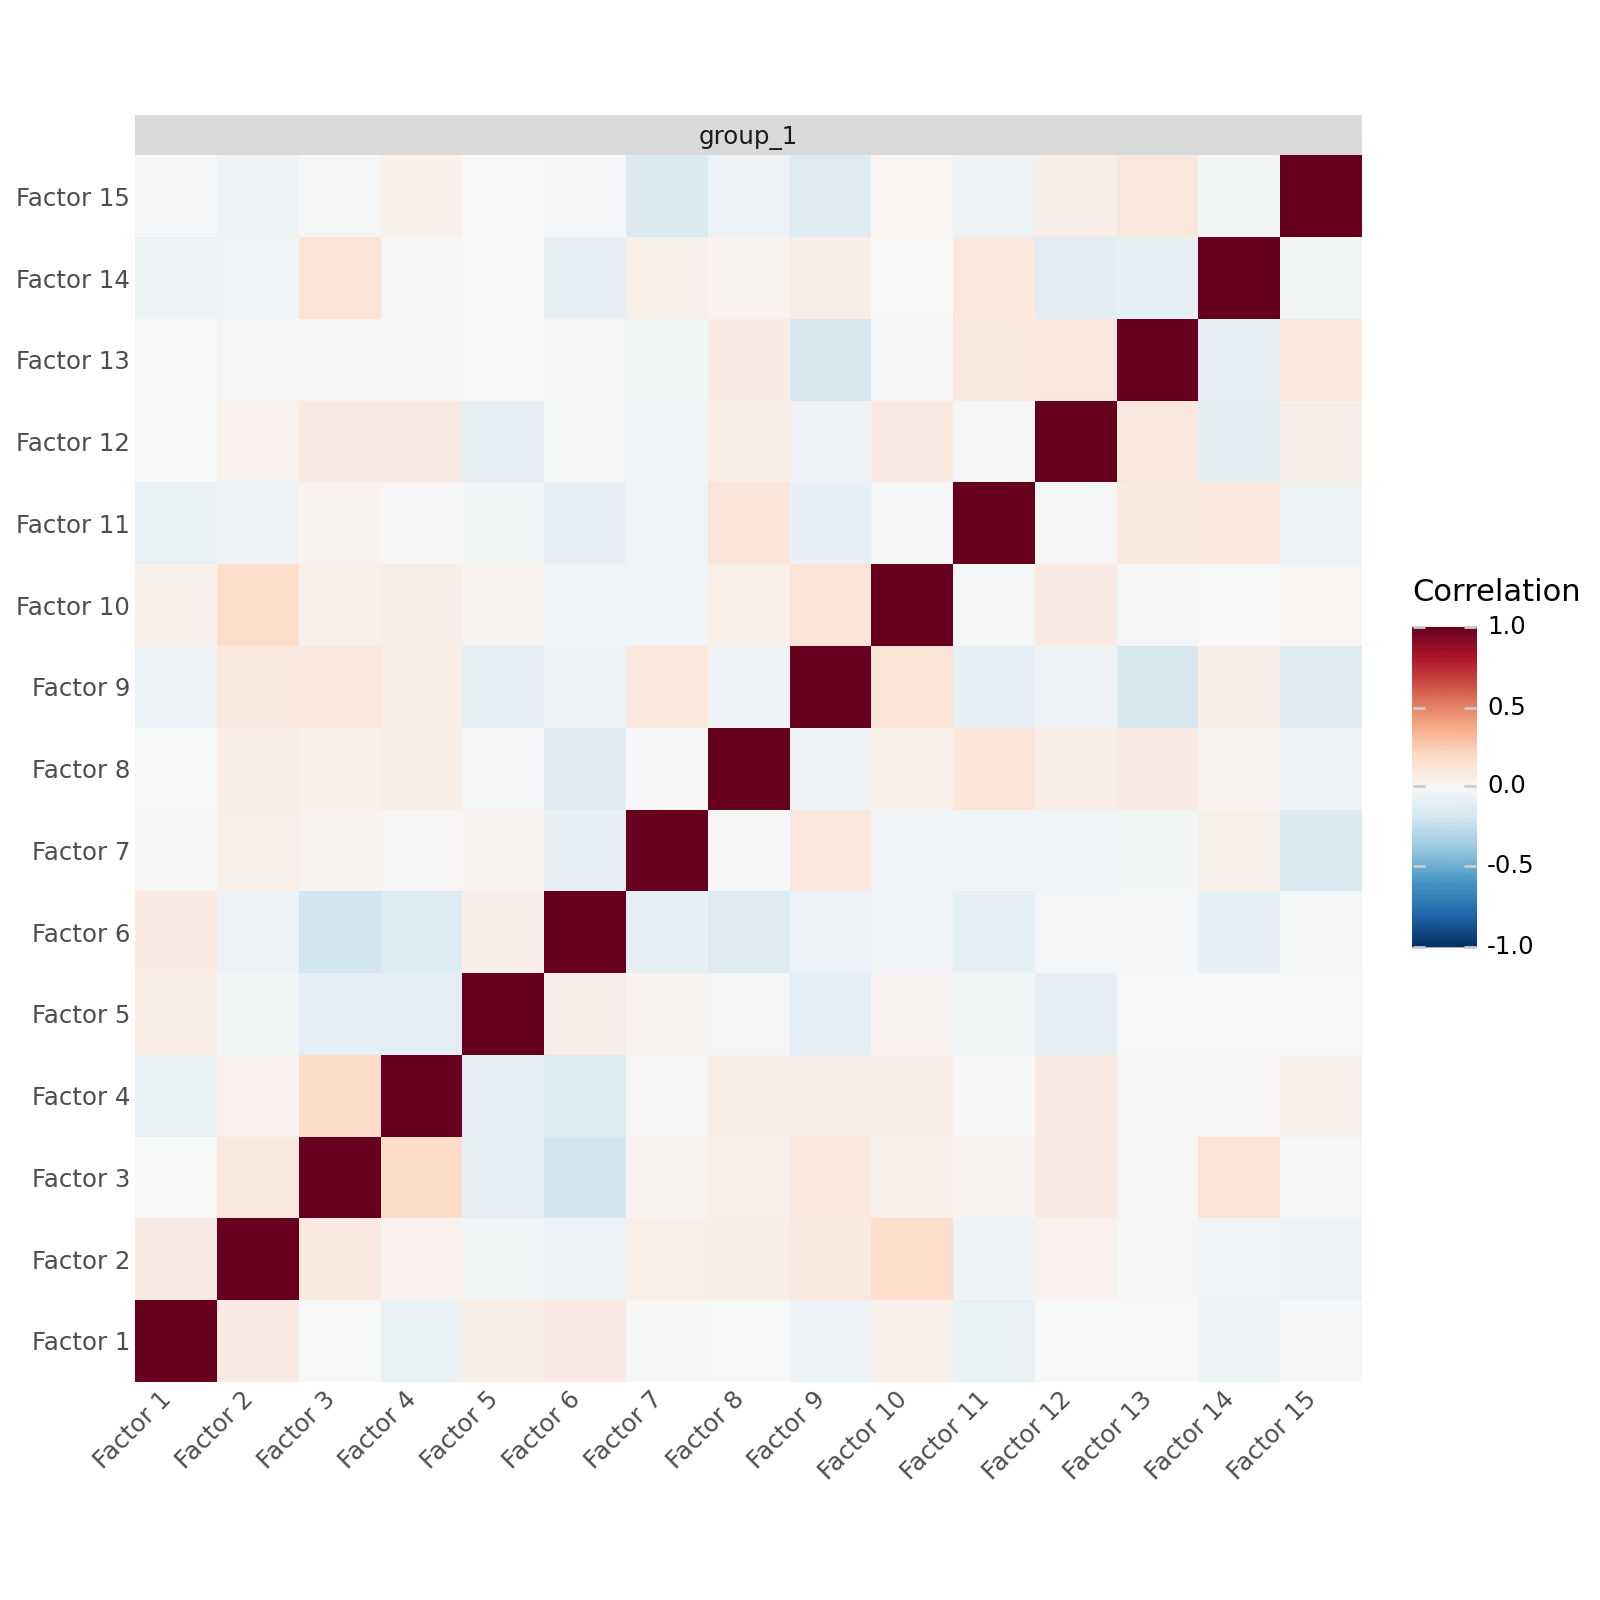

In [4]:
mfl.pl.factor_correlation(model)

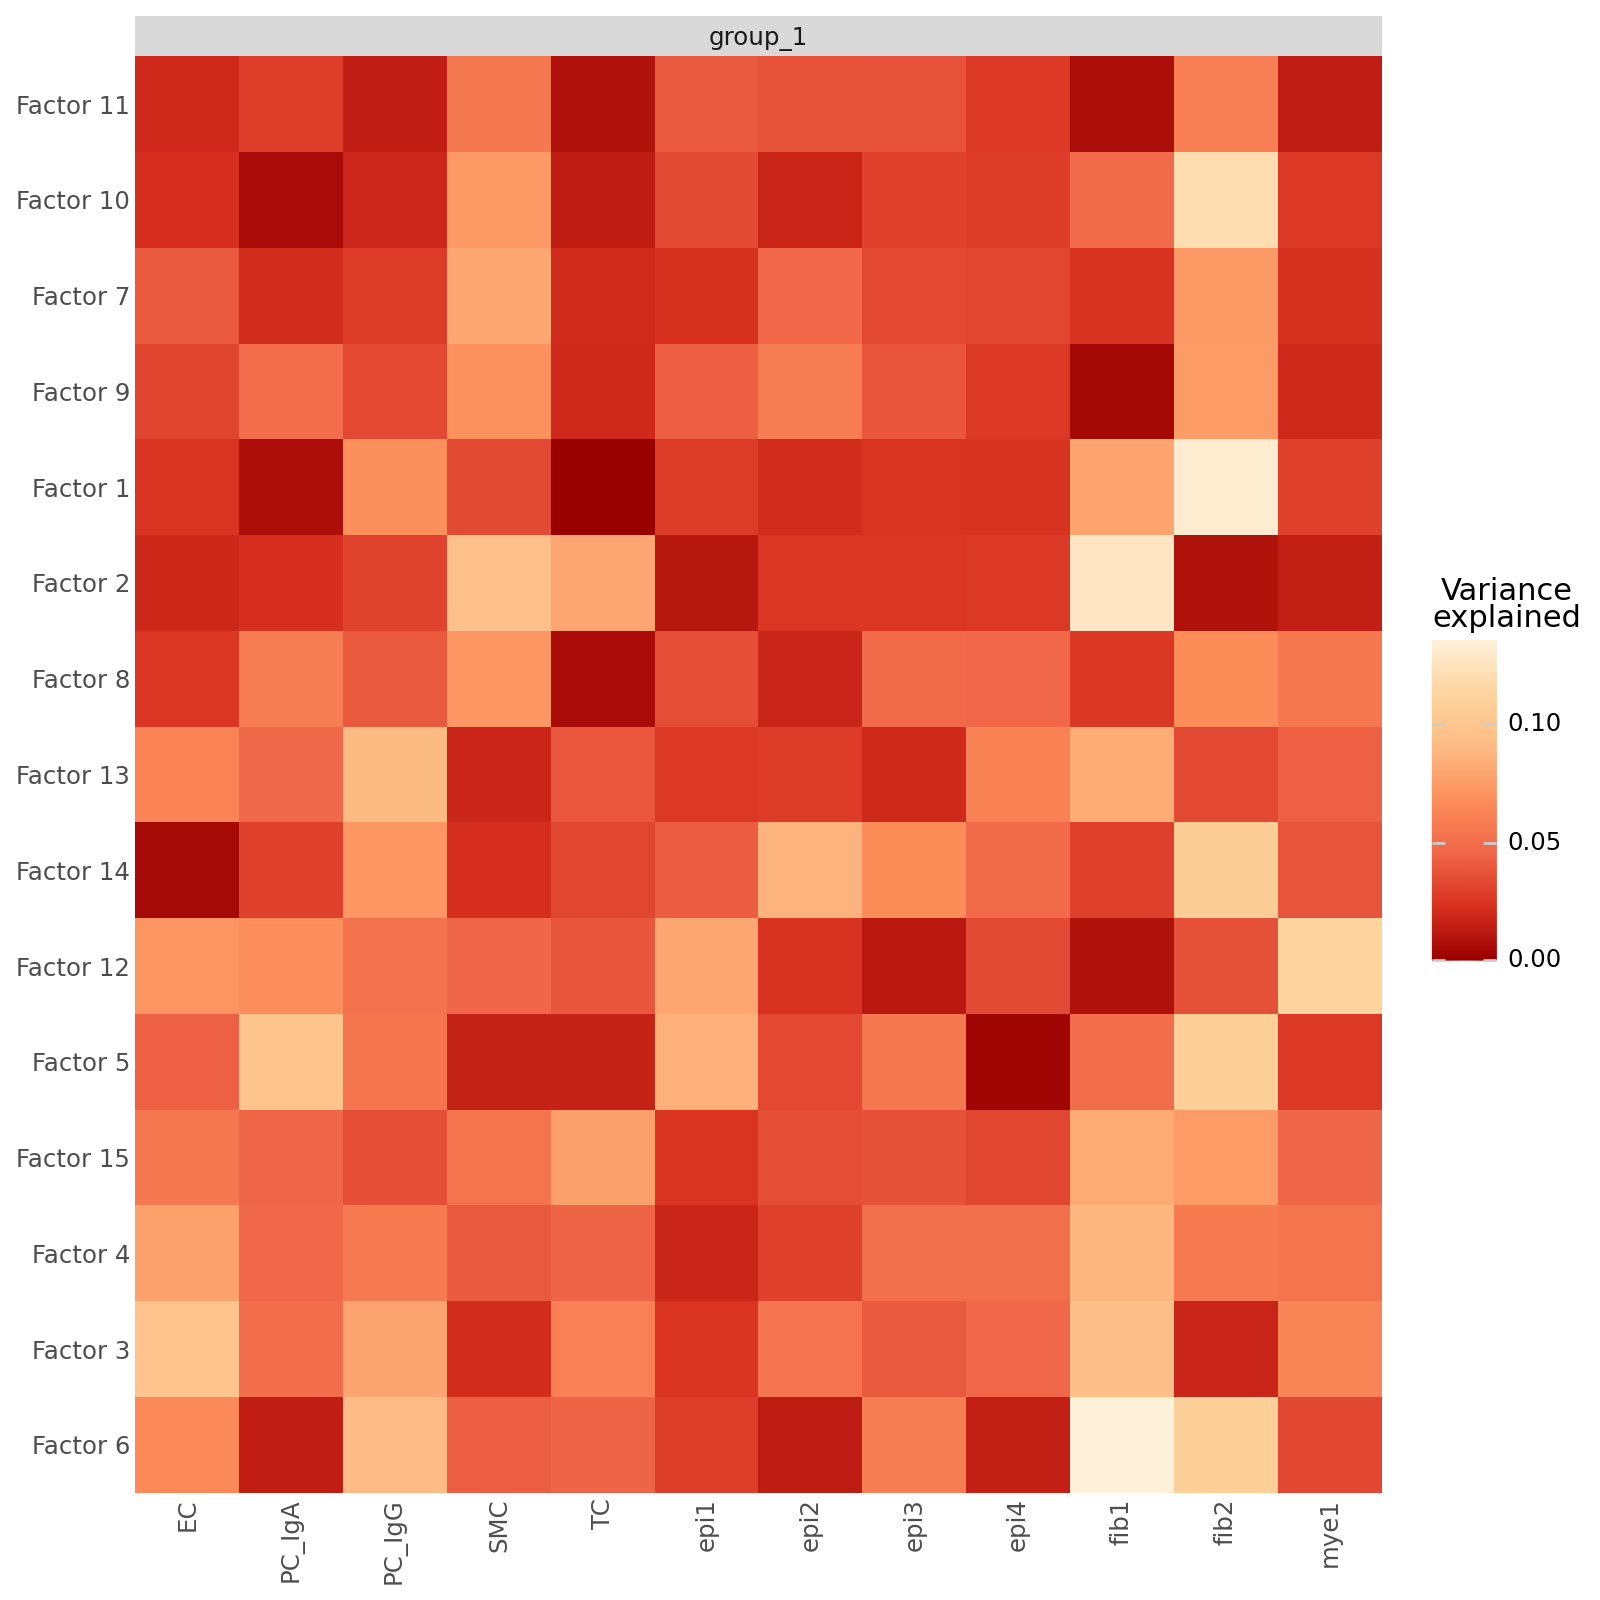

In [5]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [6]:
print(model.get_r2(total=True))

         group_1
epi4    0.525358
epi2    0.457083
epi1    0.517178
epi3    0.557948
mye1    0.571551
fib2    0.957233
EC      0.558809
TC      0.571345
SMC     0.808366
fib1    0.840767
PC_IgG  0.621116
PC_IgA  0.623549


In [7]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

np.float64(0.6341917503642843)

## 3.Weights dist

In [66]:
weights_dict= model.get_weights()

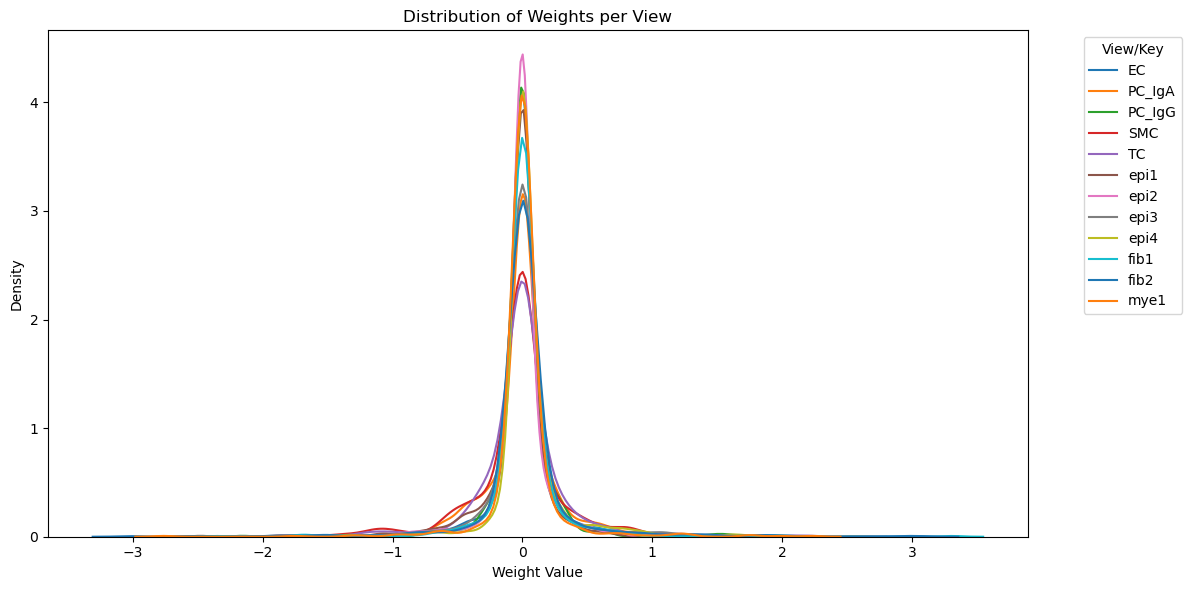

In [67]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [68]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [69]:
weights = model.get_weights()

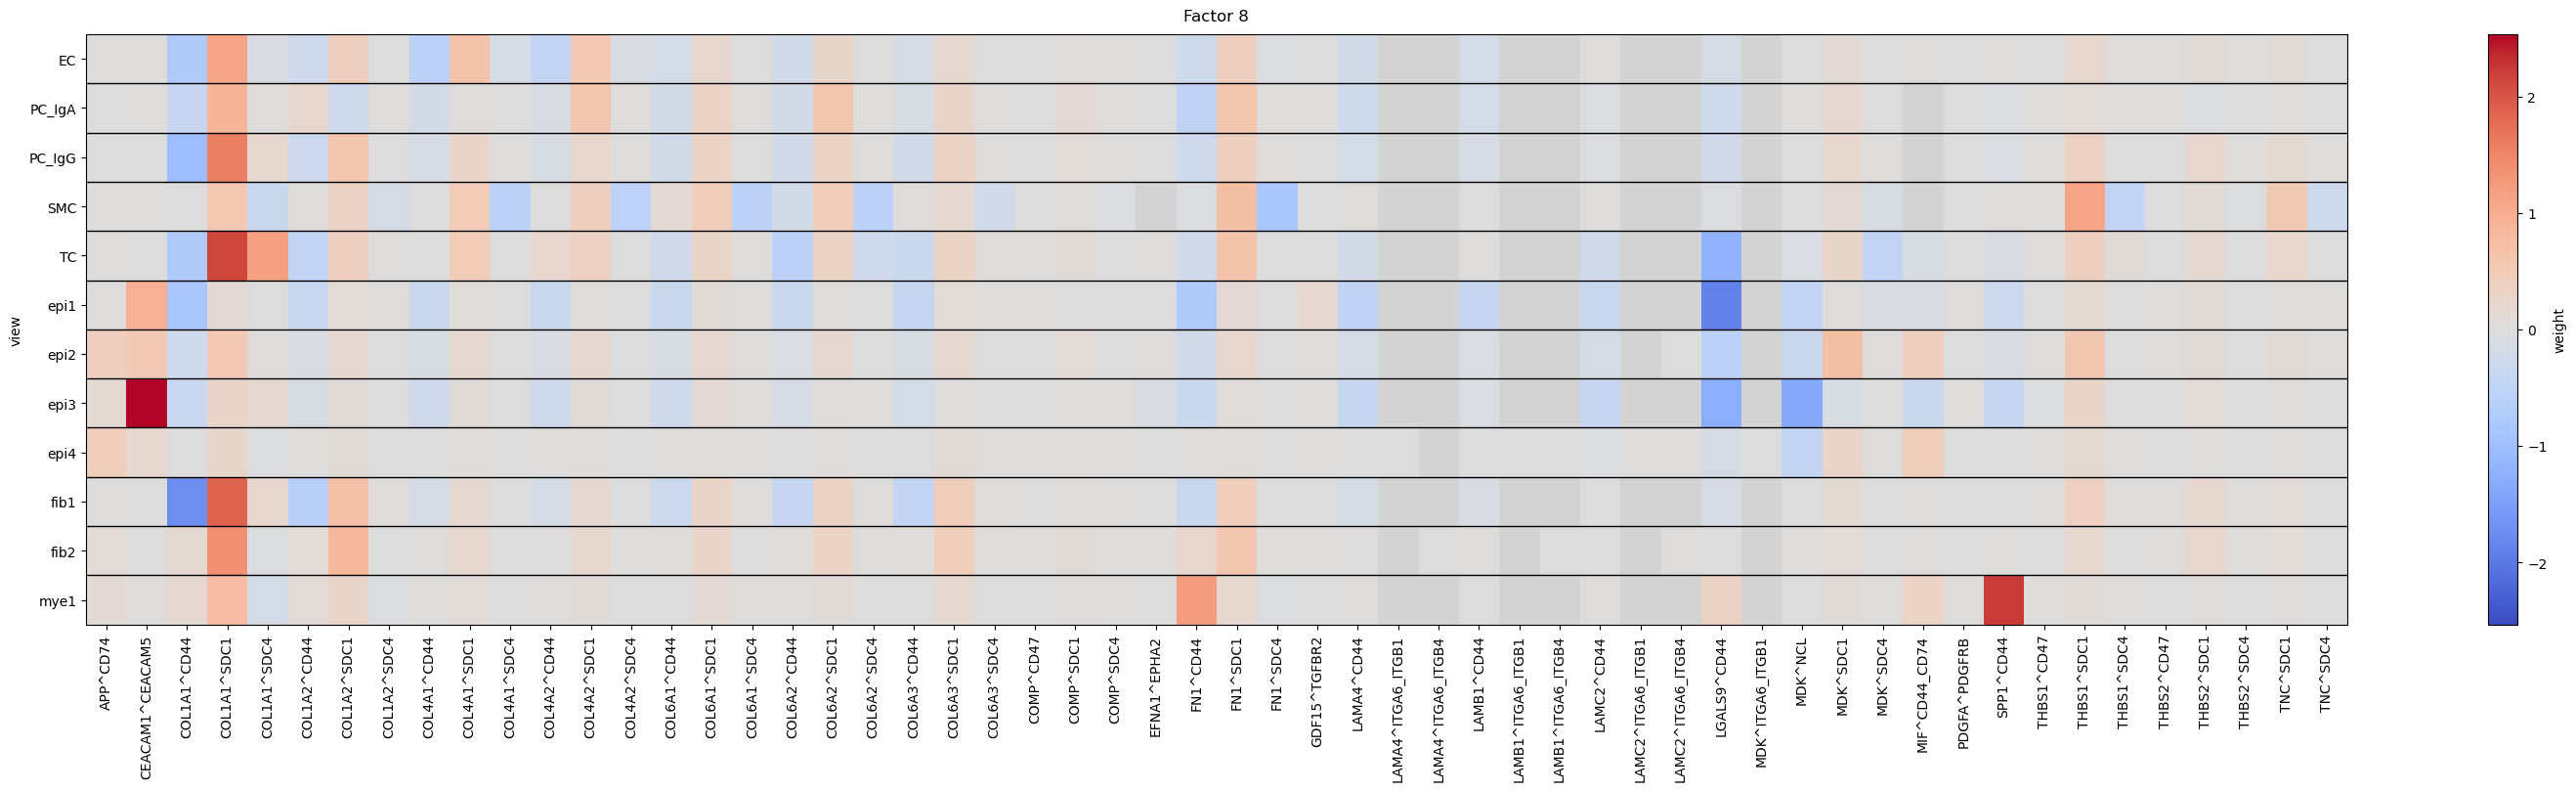

In [70]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 8

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


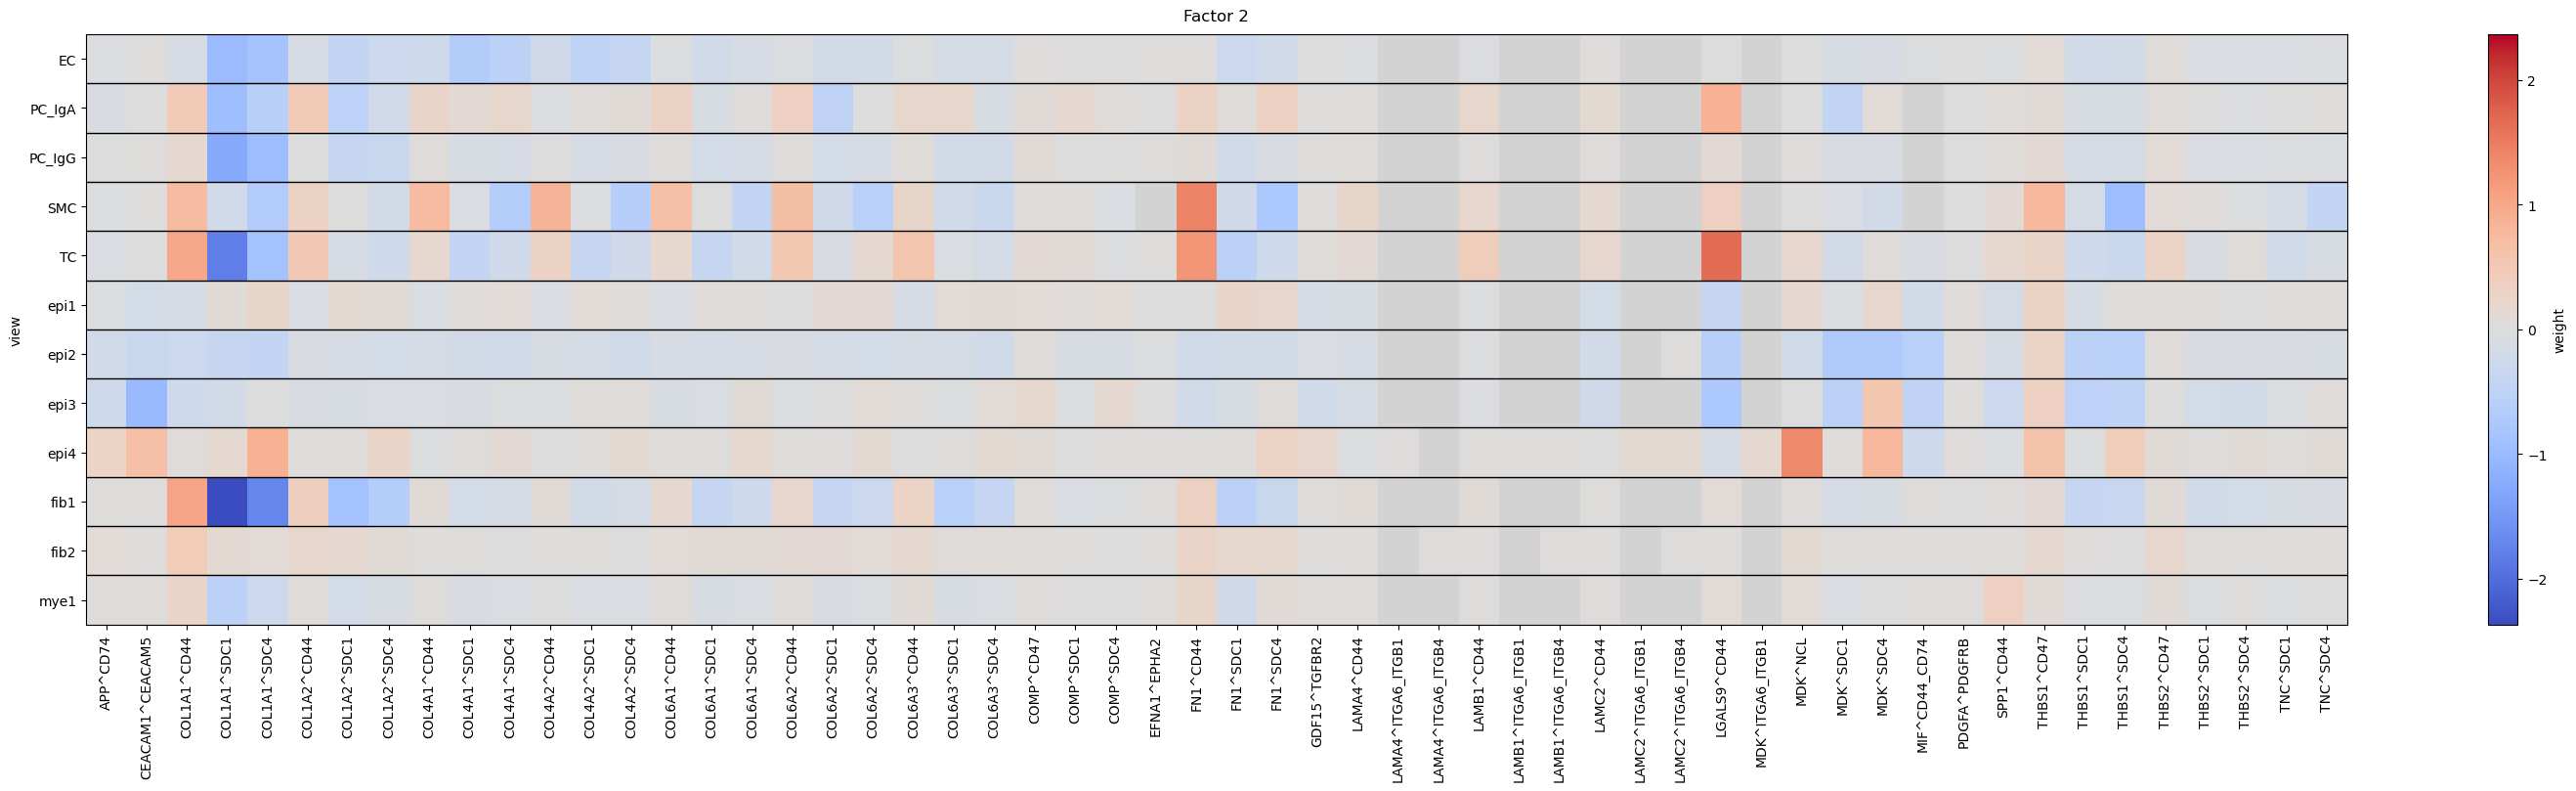

In [50]:

# choose the factor you want:
factor = 2

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [8]:
factors = model.get_factors()
factors = factors["group_1"]

In [9]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_154_37,0.132779,0.142480,0.975769,-0.556895,-0.927954,-0.384908,-0.020059,-0.587895,0.183824,-0.096323,-0.342487,-0.250388,-0.684398,1.148717,-0.270025
c_3_154_43,0.294566,0.008033,0.433853,-0.103059,-0.592117,0.132746,-0.211608,-0.366292,0.001529,1.140662,-0.245005,0.175639,-0.221797,0.418301,0.040954
c_3_154_61,-0.190235,-0.460681,0.565774,-0.294287,-0.051914,0.313991,-0.410119,-0.363320,0.337479,0.763851,0.259194,-0.365572,-0.298421,-0.287144,0.161366
c_3_154_69,-0.096173,-0.078650,-0.326810,0.341373,-0.325778,-0.193075,-0.247690,-0.048396,0.051235,0.656726,0.387509,-0.128258,0.342003,-0.051961,0.709008
c_3_154_75,-0.077283,0.222358,-0.242813,-0.222596,-0.340299,-0.375647,-0.651844,0.277687,0.352592,0.324416,0.108394,0.194084,0.450819,-0.154401,0.772074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_163_214,0.681667,-0.008299,0.193849,-0.670376,0.078092,-0.093796,-0.584809,0.224866,-0.228838,-0.318902,-0.881349,0.484895,-0.342769,0.137890,0.730775
c_3_163_1843,-0.849747,-0.998791,1.644473,-0.180919,-0.626920,0.791192,1.100312,-1.278113,-1.091323,0.057494,1.031343,1.674226,0.073975,0.513531,-0.487985
c_3_163_2575,0.903031,-0.958014,-0.743372,-0.516569,-0.043565,-0.020973,0.178430,0.401002,-1.188670,-0.269057,-0.206928,0.435796,-0.394546,-0.237796,-0.170495
c_3_164_158,-0.926580,-0.738160,-0.697822,0.337824,1.279668,0.226298,0.154370,-1.261031,-0.011495,-0.270136,0.051235,-0.908782,-0.556201,-0.780334,0.904580


In [10]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(20377,)

## UMAP

In [11]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [12]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [13]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [14]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=6, noise=8.63%


#### 2D UMAP

In [15]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [16]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

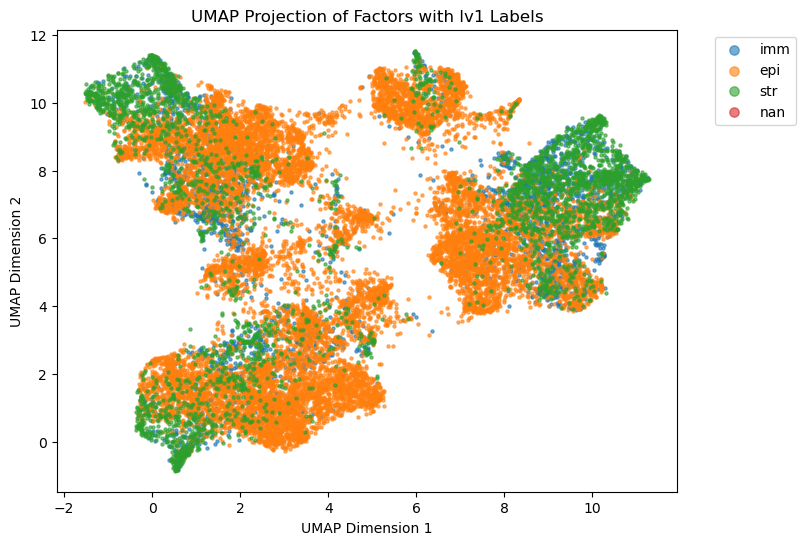

In [15]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

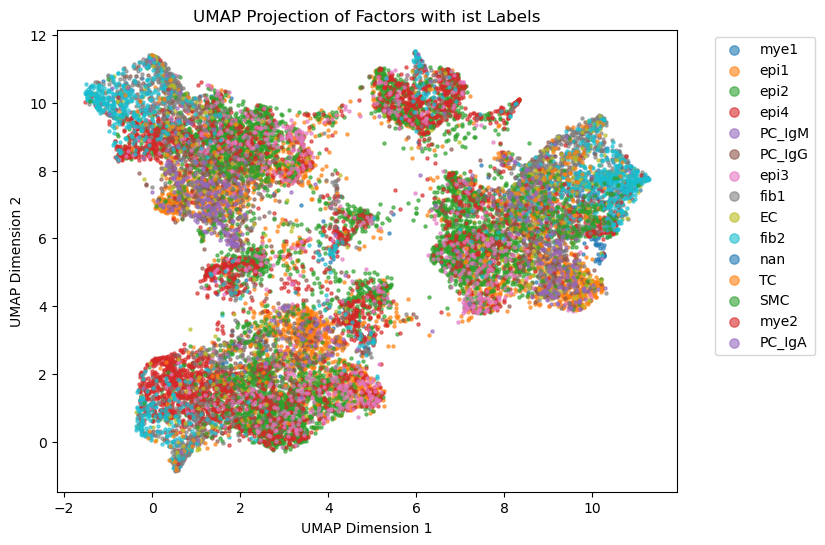

In [16]:
df_umap['Label'] = ist.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with ist Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

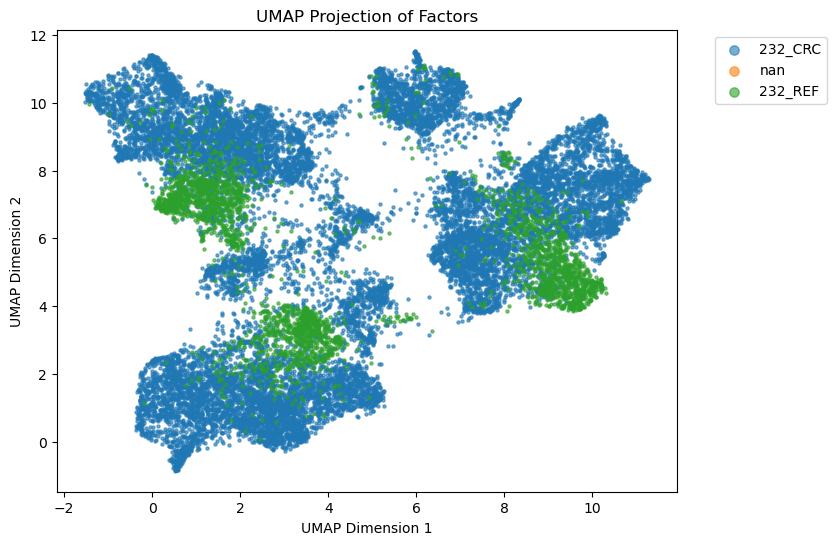

In [17]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

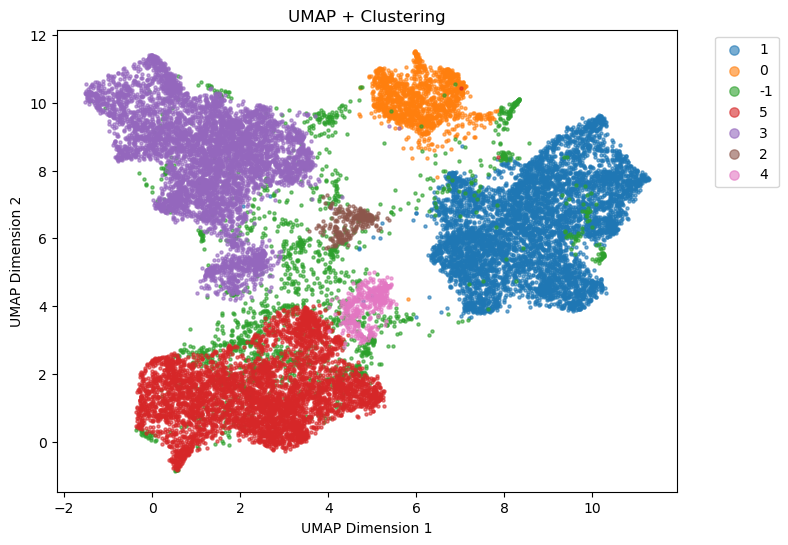

In [18]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [19]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
c_3_154_37,7.284192,7.744848,1,1.000000,232_CRC
c_3_154_43,6.756730,9.643015,0,0.752868,232_CRC
c_3_154_61,3.038893,1.715372,-1,0.000000,232_CRC
c_3_154_69,3.084451,1.321105,5,0.915297,232_CRC
c_3_154_75,2.195687,0.487721,5,1.000000,232_CRC
...,...,...,...,...,...
c_3_163_214,1.408516,6.290531,3,1.000000,232_REF
c_3_163_1843,2.205639,3.253726,-1,0.000000,232_REF
c_3_163_2575,1.612729,9.464395,3,1.000000,232_REF
c_3_164_158,1.162243,8.078731,3,1.000000,232_REF


In [87]:
interactions_fib2 = [g for g in lrdata.var_names if g.startswith("fib2")]
print(interactions_fib2)

['fib2^CEACAM1^CEACAM5', 'fib2^MDK^NCL', 'fib2^APP^CD74', 'fib2^GDF15^TGFBR2', 'fib2^COL4A1^SDC4', 'fib2^COL4A2^SDC4', 'fib2^SPP1^CD44', 'fib2^PDGFA^PDGFRB', 'fib2^COL6A1^SDC4', 'fib2^THBS2^CD47', 'fib2^COL6A2^SDC4', 'fib2^TNC^SDC4', 'fib2^COL4A2^CD44', 'fib2^FN1^SDC4', 'fib2^LAMA4^CD44', 'fib2^COL1A2^SDC4', 'fib2^COL6A3^SDC4', 'fib2^THBS1^CD47', 'fib2^COL4A1^CD44', 'fib2^LAMB1^CD44', 'fib2^COL6A2^CD44', 'fib2^COL1A1^SDC4', 'fib2^COL6A3^CD44', 'fib2^COL1A2^CD44', 'fib2^COL6A1^CD44', 'fib2^MDK^SDC4', 'fib2^FN1^CD44', 'fib2^THBS1^SDC4', 'fib2^COMP^CD47', 'fib2^LGALS9^CD44', 'fib2^THBS2^SDC4', 'fib2^COL1A1^CD44', 'fib2^LAMC2^CD44', 'fib2^COL4A2^SDC1', 'fib2^COL4A1^SDC1', 'fib2^COL6A2^SDC1', 'fib2^COL6A1^SDC1', 'fib2^COL6A3^SDC1', 'fib2^TNC^SDC1', 'fib2^FN1^SDC1', 'fib2^COL1A2^SDC1', 'fib2^MDK^SDC1', 'fib2^THBS2^SDC1', 'fib2^COMP^SDC4', 'fib2^THBS1^SDC1', 'fib2^COMP^SDC1', 'fib2^COL1A1^SDC1', 'fib2^EFNA1^EPHA2', 'fib2^MIF^CD44_CD74', 'fib2^LAMC2^ITGA6_ITGB4', 'fib2^LAMB1^ITGA6_ITGB4', 'fib

In [88]:
df_umap["fib2_mean"] = lrdata[factors.index, interactions_fib1].to_df().mean(axis=1)

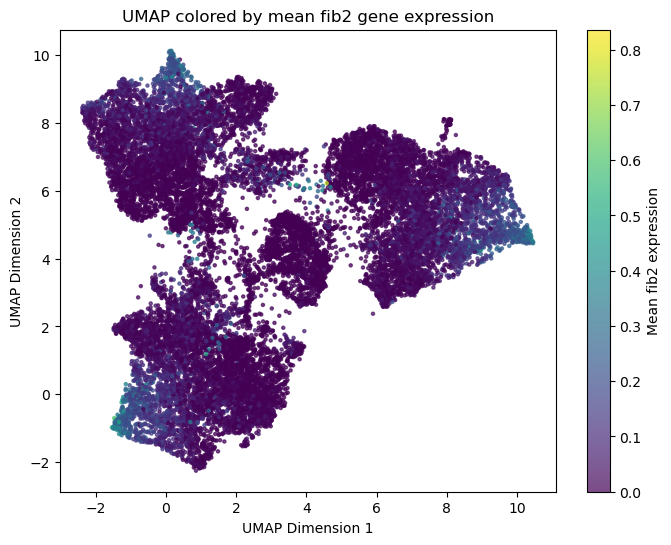

In [89]:
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df_umap['UMAP1'], df_umap['UMAP2'],
    c=df_umap["fib2_mean"], cmap="viridis", s=5, alpha=0.7
)
plt.colorbar(sc, label="Mean fib2 expression")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP colored by mean fib2 gene expression")
plt.show()

# Regression Model

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [91]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["lv1"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [92]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_147_106,0.437908,-0.427744,1.728303,0.061906,0.079416,0.654957,0.227994,-0.626212,-1.162632,0.972329,-0.845887,0.551037,-0.319021,-1.621253,0.854544
c_3_147_69,0.151557,-0.747074,0.049643,-0.133049,0.284451,0.492540,-0.183948,-0.435116,-0.966544,-0.647700,0.037770,-0.675650,0.391747,0.742852,-0.004877
c_3_148_110,-0.179295,0.723299,-0.176057,0.673504,-0.365837,-1.333852,-0.784225,-0.902135,0.590824,-1.078367,1.033791,0.046524,0.745617,0.118650,0.133397
c_3_148_120,2.711747,-1.070948,-2.092992,-0.431484,1.287990,0.203426,3.152383,-0.574160,-0.011436,-0.526639,-0.267513,-0.319344,0.539518,2.025976,0.785979
c_3_148_121,2.504980,-0.236531,1.167153,-0.208792,0.149184,-0.922633,0.898113,-0.478094,0.175041,1.008053,-0.008334,-0.192691,-0.524433,-1.941445,-0.561236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_217_975,-0.796313,-2.304187,-0.199751,0.476298,0.563126,0.288885,1.147145,-0.165442,-0.484185,0.299892,1.087748,0.768449,-0.874831,0.607759,0.146090
c_3_217_977,1.001008,0.431399,-0.025350,0.294638,0.263722,-0.022182,-0.523909,-0.752164,0.434422,-0.632051,0.563670,0.316817,-0.112120,0.149905,-0.341954
c_3_217_979,-0.241620,0.242414,0.005104,-0.218027,0.220378,0.892406,-0.357794,-1.004620,-1.296693,-0.941794,-0.884828,0.404330,0.209779,-0.065260,-0.106154
c_3_217_98,-0.372148,-0.355338,1.298914,0.991088,-0.643462,-0.467784,0.214051,-0.011499,-0.690621,-0.451916,-0.310710,-0.504882,0.366844,-1.076628,-0.067392


In [93]:
filtered_cell_types

c_3_147_106    epi
c_3_147_69     NaN
c_3_148_110    imm
c_3_148_120    str
c_3_148_121    NaN
              ... 
c_3_217_975    epi
c_3_217_977    imm
c_3_217_979    imm
c_3_217_98     str
c_3_217_989    imm
Name: lv1, Length: 20377, dtype: category
Categories (3, object): ['epi', 'imm', 'str']

In [94]:
X = F.values
y = filtered_cell_types.values  # labels

In [95]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [96]:
print(X.shape, y.shape)

(20103, 15) (20103,)


In [97]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -6.890287
Max: 6.8716254
Mean: -0.02179292
Median: -0.017269393
Std dev: 0.8153857


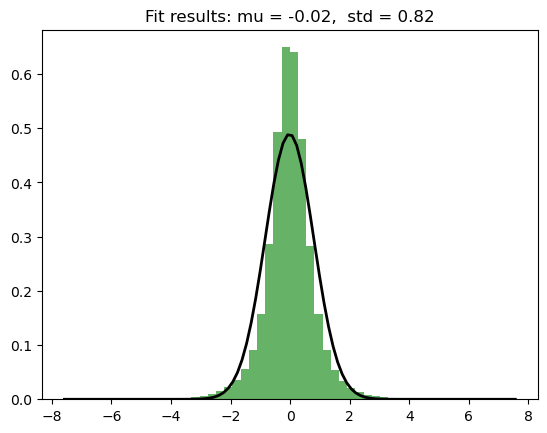

In [98]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [99]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [100]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [101]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [102]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5607693583153706

Classification Report:
               precision    recall  f1-score   support

         epi       0.81      0.61      0.70      4044
         imm       0.26      0.39      0.31       936
         str       0.34      0.51      0.41      1051

    accuracy                           0.56      6031
   macro avg       0.47      0.50      0.47      6031
weighted avg       0.64      0.56      0.59      6031



### AUC

In [103]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

In [104]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="232_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ValueError: multi_class must be in ('ovo', 'ovr')

#### 2. If classes are more than 2:

In [105]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.6979
Multiclass ROC AUC (OvR, weighted): 0.7082


# Map clusters to spatial 

In [106]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label,fib2_mean
c_3_154_37,6.008451,5.120210,2,0.838633,232_CRC,0.007769
c_3_154_43,3.065812,3.715438,0,0.617681,232_CRC,0.002424
c_3_154_61,1.349808,4.231586,-1,0.000000,232_CRC,0.000000
c_3_154_69,0.556114,7.272332,4,1.000000,232_CRC,0.000000
c_3_154_75,-0.445271,6.428650,4,0.980438,232_CRC,0.018233
...,...,...,...,...,...,...
c_3_163_214,1.203853,0.638515,1,0.770138,232_REF,0.003312
c_3_163_1843,1.177347,8.974927,4,0.902858,232_REF,0.000000
c_3_163_2575,0.811251,3.195480,1,1.000000,232_REF,0.002561
c_3_164_158,0.090756,2.292037,1,0.735498,232_REF,0.002283


In [107]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 109538


In [108]:
lrdata.obs['Cluster'] = clusters.astype('category')

In [109]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()

AttributeError: 'PathCollection' object has no attribute 'pl'

# Spatial accuracy benchmark

In [111]:
from scipy.spatial import *
from sklearn.preprocessing import *

from sklearn.metrics import *
from scipy.spatial.distance import *

Accuracy vs. ground truth annotations: NMI (normalized mutual information).

Spatial continuity/compactness: ASW (silhouette).

ARI


### ASW: Silhouette score of all data points, which quantifies how well clusters are separated

In [114]:
def compute_ASW(adata, pred_key, spatial_key='spatial'):
    d = squareform(pdist(adata.obsm[spatial_key]))  # pairwise distance matrix
    return silhouette_score(
        X=d,
        labels=adata.obs[pred_key],
        metric='precomputed'
    )

### Remove NA

In [115]:
lrdata_clean = lrdata[~lrdata.obs["Cluster"].isna()].copy()

### Remove noise cluster

In [116]:
# Keep only rows where Cluster != -1
lrdata_no_noise = lrdata_clean[lrdata_clean.obs["Cluster"] != -1].copy()

In [117]:
lrdata_no_noise.obs["Cluster"]

c_3_147_69      2.0
c_3_147_106     1.0
c_3_148_28      2.0
c_3_148_61      1.0
c_3_148_74      4.0
               ... 
c_3_217_1890    2.0
c_3_217_1892    1.0
c_3_217_1893    4.0
c_3_217_1912    0.0
c_3_217_1919    2.0
Name: Cluster, Length: 18777, dtype: category
Categories (5, float64): [0.0, 1.0, 2.0, 3.0, 4.0]

## Compute ASW

In [118]:
compute_ASW(lrdata_no_noise, "Cluster", "spatial")

np.float64(-0.09315622302040084)

## NMI

In [101]:
lrdata_clean2 = lrdata_no_noise[~lrdata_no_noise.obs["ist"].isna()].copy()

In [119]:
normalized_mutual_info_score(lrdata_clean2.obs["ist"],lrdata_clean2.obs["Cluster"])
#GP = 0.020449639085338686

NameError: name 'lrdata_clean2' is not defined

## ARI

In [ ]:
adjusted_rand_score(lrdata_clean2.obs["typ"],lrdata_clean2.obs["Cluster"])
#GP: 0.031241352304798475

-0.031241352304798475

# Factor scores & clusters with metadata

In [17]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [39]:
cat = lrdata.obs["lv1"]

In [40]:
cat = cat.astype("category")

In [41]:
from statsmodels.multivariate.manova import MANOVA

df = factors.join(cat.rename("category"))
df = df.dropna()

# Build data frame with category
df = factors.join(cat.rename("category")).dropna()

# Quote all factor names so Patsy treats them as literal column names
def q(name: str) -> str:
    # Use double quotes inside Q(...) so names with single quotes also work
    return f'Q("{name}")'

lhs = " + ".join(q(c) for c in factors.columns)
# Use C(category) to be explicit it's categorical
formula = f"{lhs} ~ C(category)"

maov = MANOVA.from_formula(formula, data=df)
print(maov.mv_test())

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept        Value   Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.9255 15.0000 20080.0000 107.8332 0.0000
         Pillai's trace 0.0745 15.0000 20080.0000 107.8332 0.0000
 Hotelling-Lawley trace 0.0806 15.0000 20080.0000 107.8332 0.0000
    Roy's greatest root 0.0806 15.0000 20080.0000 107.8332 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
      C(category)       Value   Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.8795 30.0000 40160.0000  88.7985 0.0000
         Pillai's trace 0.1231

In [42]:
from scipy import stats

common_idx = factors.index.intersection(cat.index)
X = factors.loc[common_idx].copy()
y = cat.loc[common_idx]

# One-hot encode categories
Y_dummy = pd.get_dummies(y, prefix="cat")

# --- Compute correlations ---
results = []
for fac in X.columns:
    for cat in Y_dummy.columns:
        vals_x = X[fac]
        vals_y = Y_dummy[cat]
        
        # Pearson
        r, p = stats.pearsonr(vals_x, vals_y)
        
        # Spearman
        rho, p_s = stats.spearmanr(vals_x, vals_y)
        
        results.append({
            "factor": fac,
            "category": cat,
            "pearson_r": r,
            "pearson_p": p,
            "spearman_rho": rho,
            "spearman_p": p_s
        })

assoc_df = pd.DataFrame(results)

# --- Multiple testing correction (FDR) ---
from statsmodels.stats.multitest import multipletests

for pcol in ["pearson_p", "spearman_p"]:
    mask = assoc_df[pcol].notna()
    _, qvals, _, _ = multipletests(assoc_df.loc[mask, pcol], method="fdr_bh")
    assoc_df.loc[mask, pcol.replace("_p", "_q")] = qvals

# --- Inspect strongest associations ---
assoc_df = assoc_df.sort_values("pearson_r", key=lambda x: x.abs(), ascending=False)

print(assoc_df.head(10).to_string(index=False))


   factor category  pearson_r    pearson_p  spearman_rho    spearman_p    pearson_q    spearman_q
Factor 12  cat_epi   0.133344 2.183689e-80      0.160281 9.532706e-116 9.826599e-79 4.289718e-114
Factor 11  cat_str   0.132016 8.105379e-79      0.129220  1.448982e-75 1.823710e-77  1.630104e-74
Factor 12  cat_imm  -0.122355 6.933888e-68     -0.138107  3.771895e-86 1.040083e-66  5.657843e-85
 Factor 7  cat_str   0.120485 7.233969e-66      0.123259  7.146130e-69 8.138216e-65  5.359598e-68
Factor 15  cat_str  -0.106900 3.691952e-52     -0.128332  1.508515e-74 3.322757e-51  1.357664e-73
 Factor 7  cat_epi  -0.105613 6.013036e-51     -0.108493  1.112873e-53 4.509777e-50  6.259913e-53
Factor 15  cat_epi   0.105301 1.179252e-50      0.138151  3.325562e-86 7.580905e-50  5.657843e-85
 Factor 1  cat_str   0.101720 2.269522e-47      0.108971  3.843069e-54 1.276606e-46  2.470544e-53
 Factor 1  cat_epi  -0.095041 1.497826e-41     -0.106994  3.007211e-52 7.489128e-41  1.503605e-51
 Factor 3  cat_epi  

In [29]:
cat

c_3_147_1       NaN
c_3_147_2        N3
c_3_147_3        N6
c_3_147_4       NaN
c_3_147_5       NaN
               ... 
c_3_217_1942    NaN
c_3_217_1943    NaN
c_3_217_1944    NaN
c_3_217_1946    NaN
c_3_217_1947    NaN
Name: ctx, Length: 129915, dtype: category
Categories (10, object): ['N1', 'N2', 'N3', 'N4', ..., 'N7', 'N8', 'N9', 'N10']

In [30]:
common_idx = factors.index.intersection(cat.index)
factors = factors.loc[common_idx].copy()
cat = cat.loc[common_idx].dropna()
factors = factors.loc[cat.index] 

In [31]:
# Optional: drop factors that are all-NaN or constant
is_constant = factors.nunique(dropna=True) <= 1
factors = factors.loc[:, ~is_constant]

In [32]:
# --- Quick overview ---
print("Cells:", factors.shape[0], "| Factors:", factors.shape[1], "| Categories:", cat.cat.categories.tolist())
print(cat.value_counts().to_string(), "\n")

Cells: 20097 | Factors: 15 | Categories: ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10']
ctx
N3     6380
N8     2753
N6     2744
N5     2288
N10    1992
N4     1395
N1     1014
N7      748
N2      731
N9       52 



In [33]:
# --- Helper: effect size (η²) for one-way ANOVA ---
def eta_squared(groups):
    # groups: list of 1D arrays per category
    all_vals = np.concatenate(groups)
    grand_mean = np.nanmean(all_vals)
    ss_total = np.nansum((all_vals - grand_mean)**2)
    ss_between = 0.0
    for g in groups:
        g = np.asarray(g)
        gm = np.nanmean(g)
        ss_between += np.sum(~np.isnan(g)) * (gm - grand_mean)**2
    if ss_total == 0:
        return np.nan
    return ss_between / ss_total

In [34]:
# --- Per-factor tests ---
results = []
categories = cat.cat.categories.tolist()

for col in factors.columns:
    # Split factor values by category
    by_cat = [factors.loc[cat == c, col].dropna().values for c in categories]
    # Keep only groups with >=2 obs for ANOVA robustness (SciPy can run with >=1, but effect size/variance is unstable)
    valid_groups = [g for g in by_cat if len(g) >= 2]

    # Skip if fewer than 2 valid groups
    if len(valid_groups) < 2:
        res = dict(factor=col, n_groups=len(valid_groups),
                   anova_p=np.nan, eta2=np.nan, kruskal_p=np.nan)
    else:
        # ANOVA
        try:
            anova_stat, anova_p = stats.f_oneway(*valid_groups)
        except Exception:
            anova_p = np.nan

        # η²
        try:
            eta2 = eta_squared(valid_groups)
        except Exception:
            eta2 = np.nan

        # Kruskal–Wallis (non-parametric)
        try:
            kruskal_stat, kruskal_p = stats.kruskal(*valid_groups)
        except Exception:
            kruskal_p = np.nan

        res = dict(factor=col, n_groups=len(valid_groups),
                   anova_p=anova_p, eta2=eta2, kruskal_p=kruskal_p)

    # Add per-category means (handy for inspection)
    for c in categories:
        res[f"mean_{c}"] = factors.loc[lv1 == c, col].mean()

    results.append(res)

res_df = pd.DataFrame(results)

In [35]:
res_df

,factor,n_groups,anova_p,eta2,kruskal_p,mean_N1,mean_N2,mean_N3,mean_N4,mean_N5,mean_N6,mean_N7,mean_N8,mean_N9,mean_N10
0,Factor 1,10,0.000000e+00,0.046182,5.364763e-162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Factor 2,10,0.000000e+00,0.029832,5.915093e-149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Factor 3,10,0.000000e+00,0.039099,9.208953e-158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Factor 4,10,4.721237e-25,0.006786,5.739855e-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Factor 5,10,0.000000e+00,0.012592,2.329668e-39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Factor 6,10,0.000000e+00,0.040447,8.978865e-155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Factor 7,10,0.000000e+00,0.058813,2.525950e-247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Factor 8,10,0.000000e+00,0.056753,1.934755e-231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Factor 9,10,0.000000e+00,0.036551,2.956011e-143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Factor 10,10,0.000000e+00,0.024276,6.019403e-85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# --- Multiple testing correction (FDR) ---
def add_fdr(df, p_col, out_col):
    p = df[p_col].values.astype(float)
    mask = np.isfinite(p)
    q = np.full_like(p, np.nan, dtype=float)
    if mask.sum() > 0:
        _, qvals, _, _ = multipletests(p[mask], method='fdr_bh')
        q[mask] = qvals
    df[out_col] = q

add_fdr(res_df, "anova_p", "anova_q")
add_fdr(res_df, "kruskal_p", "kruskal_q")

# --- Rank by effect size (η²) then by ANOVA q-value ---
res_df = res_df.sort_values(
    by=["eta2", "anova_q"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)

print("Top factors by effect size (η²):")
print(res_df[["factor", "eta2", "anova_p", "anova_q", "kruskal_p", "kruskal_q"]].head(10).to_string(index=False))

Top factors by effect size (η²):
   factor     eta2  anova_p  anova_q     kruskal_p     kruskal_q
 Factor 7 0.058813      0.0      0.0 2.525950e-247 3.788925e-246
 Factor 8 0.056753      0.0      0.0 1.934755e-231 1.451066e-230
 Factor 1 0.046182      0.0      0.0 5.364763e-162 2.682381e-161
 Factor 6 0.040447      0.0      0.0 8.978865e-155 2.244716e-154
 Factor 3 0.039099      0.0      0.0 9.208953e-158 2.762686e-157
Factor 11 0.038205      0.0      0.0 3.354159e-158 1.257810e-157
 Factor 9 0.036551      0.0      0.0 2.956011e-143 5.542521e-143
 Factor 2 0.029832      0.0      0.0 5.915093e-149 1.267520e-148
Factor 13 0.026870      0.0      0.0 7.617734e-109 1.269622e-108
Factor 10 0.024276      0.0      0.0  6.019403e-85  8.208276e-85
